# **MÓDULO 15 - Exercício**
# Análise  - A segunda etapa da Pré Modelagem

# 1) O primeiro exercício é o de salvar a base que criaram na atividade do módulo anterior em csv e abrir ela neste arquivo.
Igual fizemos no início do módulo atual no início da primeira aula.

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px

In [5]:
#Seu código de importação aqui
df = pd.read_csv('CHURN_TELECON_MOD08_TAREFA_PARTE2.csv')
df.head(10)

,customerID,Genero,Idoso,Casado,Dependentes,Tempo_como_Cliente,Serviço de Telefone,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,Forma de Pagamento,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),NaN,1840.75,No
4,8191-XWSZG,Female,0,No,No,52,Yes,No,No internet service,No internet service,No internet service,One year,Mailed check,NaN,1022.95,No
5,9959-WOFKT,Male,0,No,Yes,71,Yes,Fiber optic,Yes,No,Yes,Two year,Bank transfer (automatic),NaN,7382.25,No
6,4190-MFLUW,Female,0,Yes,Yes,10,Yes,DSL,No,Yes,No,Month-to-month,Credit card (automatic),NaN,528.35,Yes
7,4183-MYFRB,Female,0,No,No,21,Yes,Fiber optic,No,No,No,Month-to-month,Electronic check,NaN,1862.90,No
8,8779-QRDMV,Male,1,No,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,NaN,39.65,Yes
9,1680-VDCWW,Male,0,Yes,No,12,Yes,No,No internet service,No internet service,No internet service,One year,Bank transfer (automatic),NaN,202.25,No


# 2) Comece pela análise univariada:

A) Utilize a função describe no seu dataframe, veja os insights que consegue retirar.

B) Já é possível identificar variáveis com possíveis outliers? Se sim, quais?

C) Plot gráficos que considerar importante para completar sua análise univariada. (Lembrando que sua variável preditora é o churn). Não se esqueça de trazer insights de cada gráfico plotado. Utilize pelo menos 4 variáveis distintas.

D) Verifique se os dados das variáveis Booleanas são balanceados ou não.

In [6]:
#Seu código aqui
df.describe()

,Idoso,Tempo_como_Cliente,Pagamento_Mensal,Total_Pago
count,2488.000000,2488.000000,2175.000000,2488.000000
mean,0.161576,32.352090,65.607563,2290.087178
std,0.368135,24.636885,29.931520,2264.585643
min,0.000000,0.000000,18.400000,18.800000
25%,0.000000,8.000000,39.500000,402.337500
50%,0.000000,29.000000,71.450000,1402.900000
75%,0.000000,56.000000,90.250000,3867.162500
max,1.000000,72.000000,118.650000,8564.750000


É possível ver que nas colunas tempo como cliente e pagamento mensal temos uma diferença entre a média e desvio padrão, sendo a maior diferença na coluna pagamento mensal.

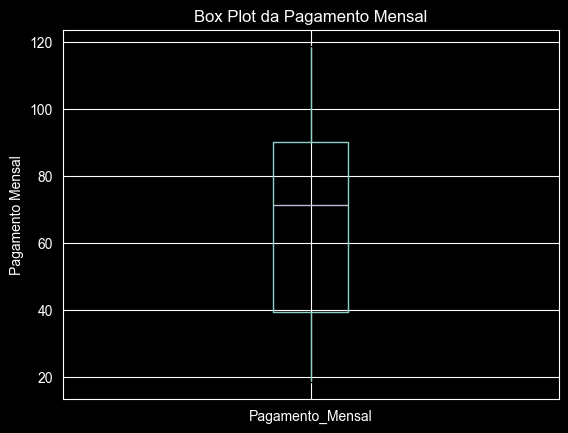

In [7]:
df.boxplot(column='Pagamento_Mensal')
plt.title('Box Plot da Pagamento Mensal')
plt.ylabel('Pagamento Mensal')
plt.show()

Aqui usei o gráfico boxplot pra ver se possuia outliers em sua diferença que vimos entre a média e desvio padrão anteriormente e vimos que a media se põe um pouco acima da linha de 60.

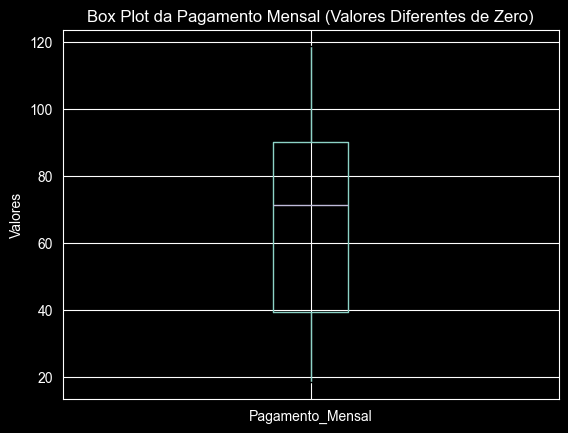

In [8]:
df_nao_zero = df[df['Pagamento_Mensal'] != 0]
df_nao_zero.boxplot(column='Pagamento_Mensal')
plt.title('Box Plot da Pagamento Mensal (Valores Diferentes de Zero)')
plt.ylabel('Valores')
plt.show()

Não vemos diferença entre os gráficos com e sem valores diferentes de zero nessa coluna de pagamento mensal.

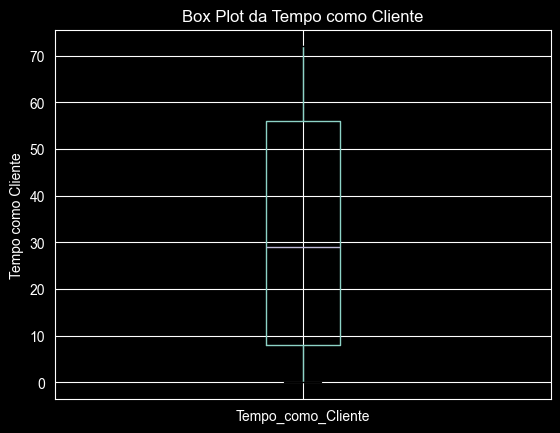

In [9]:
df.boxplot(column='Tempo_como_Cliente')
plt.title('Box Plot da Tempo como Cliente')
plt.ylabel('Tempo como Cliente')
plt.show()

Já aqui vemos a média um pouco abaixo da linha de 30 com os valores variando entre abaixo de 10 e acima de 50.

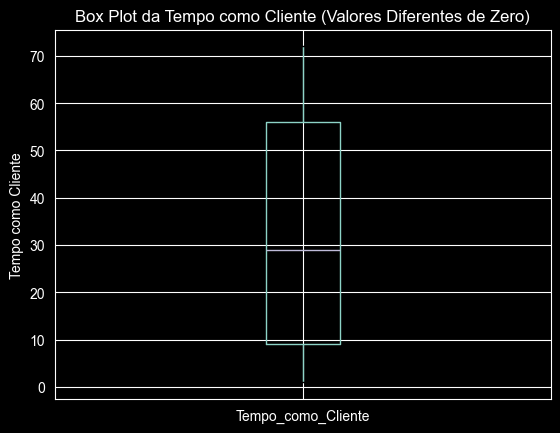

In [10]:
df_nao_zero = df[df['Tempo_como_Cliente'] != 0]
df_nao_zero.boxplot(column='Tempo_como_Cliente')
plt.title('Box Plot da Tempo como Cliente (Valores Diferentes de Zero)')
plt.ylabel('Tempo como Cliente')
plt.show()

Assim como na coluna pagamento mensal, aqui não vemos diferença considerável entre os gráficos com e sem números diferentes de zero nessa coluna de tempo como cliente.

Text(0, 0.5, 'Frequência')

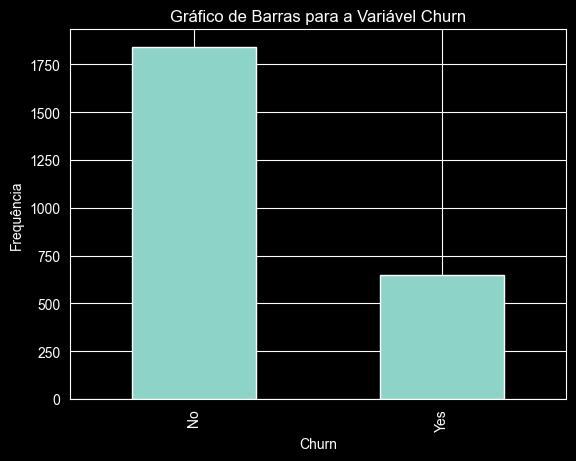

In [11]:
contagem_churn = df['Churn'].value_counts()

porcentagem_churn = (contagem_churn / contagem_churn.sum()) * 100
ax = contagem_churn.plot(kind='bar')
plt.title('Gráfico de Barras para a Variável Churn')
plt.xlabel('Churn')
plt.ylabel('Frequência')

In [12]:
contagem_churn = df['Churn'].value_counts()
(contagem_churn / contagem_churn.sum()) * 100

Churn
No     73.995177
Yes    26.004823
Name: count, dtype: float64

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12468\3097501493.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(i, v + 1, f'{porcentagem[i]:.2f}%', ha='center')


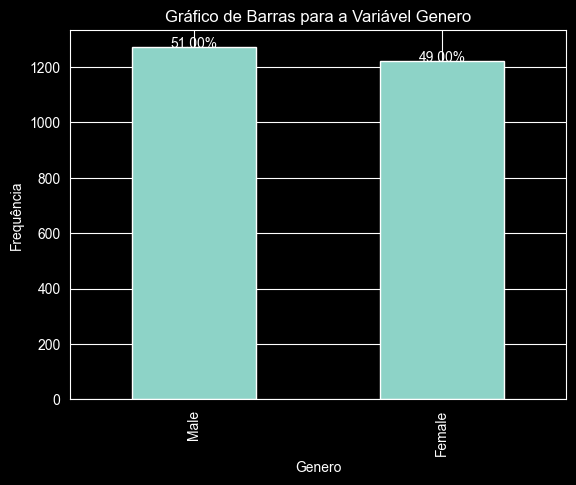

In [15]:
contagem = df['Genero'].value_counts()
porcentagem = (contagem / contagem.sum()) * 100

ax = contagem.plot(kind='bar')

for i, v in enumerate(contagem):
    ax.text(i, v + 1, f'{porcentagem[i]:.2f}%', ha='center')
plt.title('Gráfico de Barras para a Variável Genero')
plt.xlabel('Genero')
plt.ylabel('Frequência')

plt.show()

Temos um certo equilibrio entre homens e mulheres que contratam nossos serviços

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12468\2866423192.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(i, v + 1, f'{porcentagem[i]:.2f}%', ha='center')


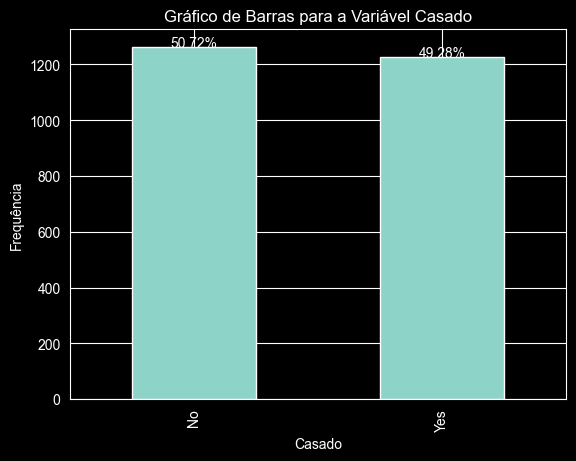

In [16]:
contagem = df['Casado'].value_counts()
porcentagem = (contagem / contagem.sum()) * 100

ax = contagem.plot(kind='bar')

for i, v in enumerate(contagem):
    ax.text(i, v + 1, f'{porcentagem[i]:.2f}%', ha='center')
plt.title('Gráfico de Barras para a Variável Casado')
plt.xlabel('Casado')
plt.ylabel('Frequência')

plt.show()

Assim como na variável gênero, na variável casado temos um equilíbrio entre pessoas que são casadas e que não são.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12468\3405416584.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(i, v + 1, f'{porcentagem[i]:.2f}%', ha='center')


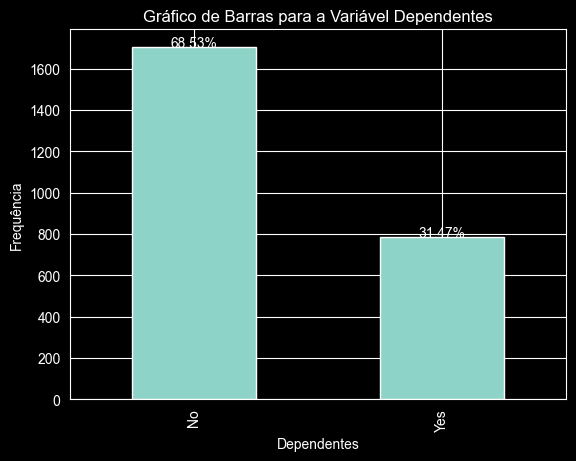

In [17]:
contagem = df['Dependentes'].value_counts()
porcentagem = (contagem / contagem.sum()) * 100

ax = contagem.plot(kind='bar')

for i, v in enumerate(contagem):
    ax.text(i, v + 1, f'{porcentagem[i]:.2f}%', ha='center')
plt.title('Gráfico de Barras para a Variável Dependentes')
plt.xlabel('Dependentes')
plt.ylabel('Frequência')

plt.show()

Aqui já temos uma grande diferença entre as pessoas que possuem dependentes ou não, sendo muito maior para as que não possuem.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12468\1196112494.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(i, v + 1, f'{porcentagem[i]:.2f}%', ha='center')


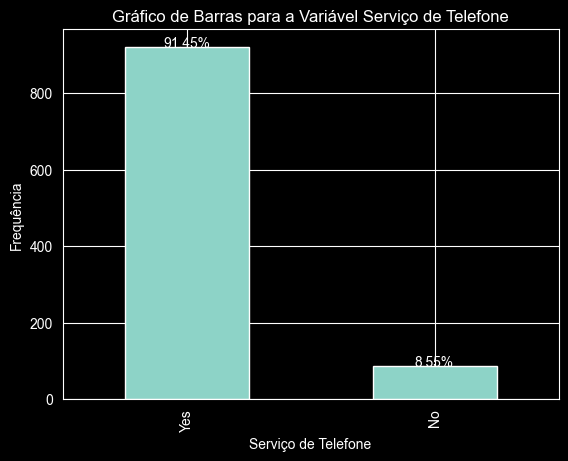

In [20]:
contagem = df['Serviço de Telefone'].value_counts()
porcentagem = (contagem / contagem.sum()) * 100

ax = contagem.plot(kind='bar')

for i, v in enumerate(contagem):
    ax.text(i, v + 1, f'{porcentagem[i]:.2f}%', ha='center')
plt.title('Gráfico de Barras para a Variável Serviço de Telefone')
plt.xlabel('Serviço de Telefone')
plt.ylabel('Frequência')

plt.show()

Temos grande diferença entre as pessoas que possuem serviço de telefone ou não.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12468\3653358306.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(i, v + 1, f'{porcentagem[i]:.2f}%', ha='center')


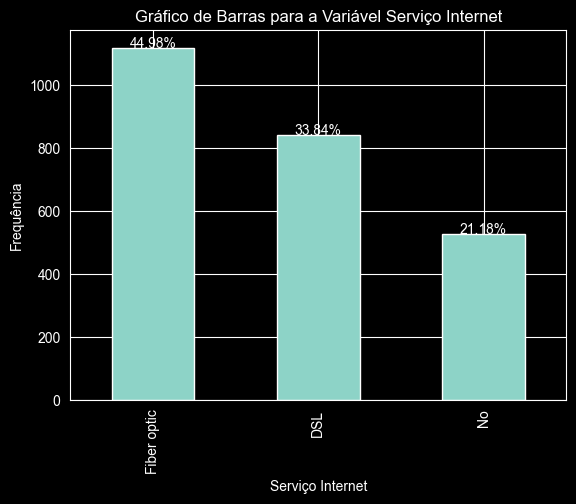

In [22]:
contagem = df['Servico_Internet'].value_counts()
porcentagem = (contagem / contagem.sum()) * 100

ax = contagem.plot(kind='bar')

for i, v in enumerate(contagem):
    ax.text(i, v + 1, f'{porcentagem[i]:.2f}%', ha='center')
plt.title('Gráfico de Barras para a Variável Serviço Internet')
plt.xlabel('Serviço Internet')
plt.ylabel('Frequência')

plt.show()

Vemos que temos mais clientes usando fibra optica do que dsl e que temos uma boa porcentagem de pessoas que não possuem esse serviço.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12468\1130748394.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(i, v + 1, f'{porcentagem[i]:.2f}%', ha='center')


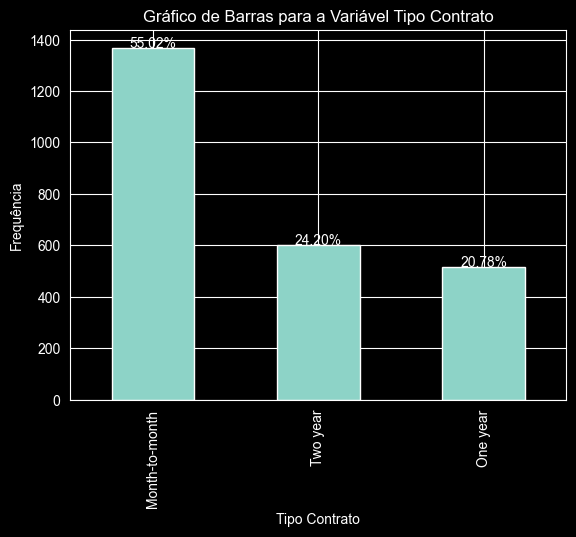

In [23]:
contagem = df['Tipo_Contrato'].value_counts()
porcentagem = (contagem / contagem.sum()) * 100

ax = contagem.plot(kind='bar')

for i, v in enumerate(contagem):
    ax.text(i, v + 1, f'{porcentagem[i]:.2f}%', ha='center')
plt.title('Gráfico de Barras para a Variável Tipo Contrato')
plt.xlabel('Tipo Contrato')
plt.ylabel('Frequência')

plt.show()

Aqui vemos que possuem mais pessoas que fazem o contrato mês a mês e sem diferenças entre as que fazem de um ou dois anos.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12468\3574881618.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(i, v + 1, f'{porcentagem[i]:.2f}%', ha='center')


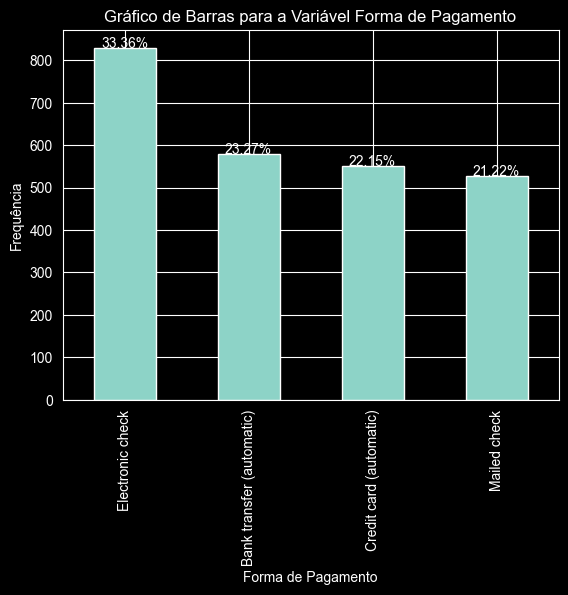

In [24]:
contagem = df['Forma de Pagamento'].value_counts()
porcentagem = (contagem / contagem.sum()) * 100

ax = contagem.plot(kind='bar')

for i, v in enumerate(contagem):
    ax.text(i, v + 1, f'{porcentagem[i]:.2f}%', ha='center')
plt.title('Gráfico de Barras para a Variável Forma de Pagamento')
plt.xlabel('Forma de Pagamento')
plt.ylabel('Frequência')

plt.show()

Aqui vemos que temos mais clientes em forma de pagamento automatizada por cheque digital e sem diferenças entre as demais formas de pagamento.

Pontuação de insights tirados da análise univariada:

-A proporção entre homens e mulheres é bem semelhante.

-Temos um equilibrio entre pessoas casadas e solteiras.

-Temos um número maior de pessoas que não possuem dependentes das que possuem.

-Mais de 90% dos clientes possuem serviço de telefone.

-Temos mais de 20% de clientes qeu não possuem serviço de internet.

-A maioria dos nossos clientes preferem fechar um contrato mês a mês do que as outras opções.

-Mais de 33% dos clientes preferem o pagamento por cheque digital à outras formas de pagamento.

# 3) Identifique e trate as colunas que contém outliers.
Caso opte por mante-los ou altera-los justifique sua escolha.


In [13]:
#Seu código aqui

Os outliers desse DataFrame já foram tratados anteriormente em outra atividade.

# 4) Realize a etapa da análise bivariada:
A) Questione pelo menos 5 informações e traga as respostas utilizando visuais gráficos e insights.


B) Quais variáveis você acredita serem as mais importantes para esse projetos relacionadas a variável Churn?

Perguntas a seres respondidas:

-As pessoas que mais dão churn são homens ou mulheres?

-São casados(as) ou solteiros(as)?

-Possuem dependentes?

-Qual o tipo de contrato desses clientes?

-E como é a forma de pagamento?

In [25]:
#Seu código aqui
df.head()

,customerID,Genero,Idoso,Casado,Dependentes,Tempo_como_Cliente,Serviço de Telefone,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,Forma de Pagamento,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),NaN,1840.75,No
4,8191-XWSZG,Female,0,No,No,52,Yes,No,No internet service,No internet service,No internet service,One year,Mailed check,NaN,1022.95,No


In [29]:
#seu códigp aqui
fig = px.histogram(df, x='Churn', color='Genero', barmode='stack')

fig.update_layout(title='Relação entre Churn e Gênero',
                  xaxis_title='Churn',
                  yaxis_title='Contagem',
                  legend_title='Gênero')
fig.show()

Vimos que a quantidade de pessoas que dão churn é baixa e que mesmo que baixa as mulheres tendem a dar churn mais que os homens.

In [32]:
fig = px.histogram(df, x='Churn', color='Casado', barmode='stack')

fig.update_layout(title='Relação entre Churn e Casado',
                  xaxis_title='Churn',
                  yaxis_title='Contagem',
                  legend_title='Casado')
fig.show()

Apesar de ser um número bem parecido entre pessoas casadas e solteiras como visto anteriormente, temos mais probabilidade de pessoas solteiras darem churn.

In [33]:
fig = px.histogram(df, x='Churn', color='Dependentes', barmode='stack')

fig.update_layout(title='Relação entre Churn e Dependentes',
                  xaxis_title='Churn',
                  yaxis_title='Contagem',
                  legend_title='Dependentes')
fig.show()

Temos maior chance de pessoas que não possuem dependentes darem churn.

In [35]:
fig = px.histogram(df, x='Churn', color='Tipo_Contrato', barmode='stack')

fig.update_layout(title='Relação entre Churn e Tipo de Contrato',
                  xaxis_title='Churn',
                  yaxis_title='Contagem',
                  legend_title='Tipo_Contrato')
fig.show()

Temos menor chance de churn de pessoas que contratam o serviço por um ou dois anos.

In [36]:
fig = px.histogram(df, x='Churn', color='Forma de Pagamento', barmode='stack')

fig.update_layout(title='Relação entre Churn e Forma de Pagamento',
                  xaxis_title='Churn',
                  yaxis_title='Contagem',
                  legend_title='Forma de Pagamento')
fig.show()

Vimos que a forma de pagamento mais utilizada é também a que possui mais probabilidade de churn.

Insights que tiramos da análise bivariada:

-Por mais baixa que pareça estar, mulheres são mais propensas a darem churn que homens.

-Pessoas solteiras dão mais churn que pessoas casadas.

-Clientes que possuem dependentes tem probabilidade maior em continuarem com o contrato.

-O contrato de mais tempo, de um e dois anos, tem menos probabilidade de ter churn do que o contrato mensal.

-Clientes com a forma de pagamento em cheque digital tem mais chance de darem churn que as demais formas de pagamento. Tendo menos na forma de cheque normal mandado por correio e automáticos como tranferência bancária ou cartão de crédito.